In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier,  bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter, plot_classification_with_grouping
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

In [2]:
# Set up experiment
def fit_gauss(counts, bins):
    params, cov = curve_fit(gaussian, bins[:-1], counts)
    return abs(params), cov

ROOT = Path("../sample_datasets/20220801_experiments/echem")
AMPLITUDES_PATH = ROOT / "amplitudes.csv"
PSD_PATH =  ROOT / "total-tail.csv"

psd = pd.read_csv(PSD_PATH, header=None)
psd = pd.DataFrame([psd[1] / psd[0]]).T
amplitudes = pd.read_csv(AMPLITUDES_PATH, header=None)
psd_report = pd.concat([psd, amplitudes], axis=1)
psd_report.columns = ["tail / total", "amplitude"]
psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]
psd_report = psd_report.dropna(axis=0)

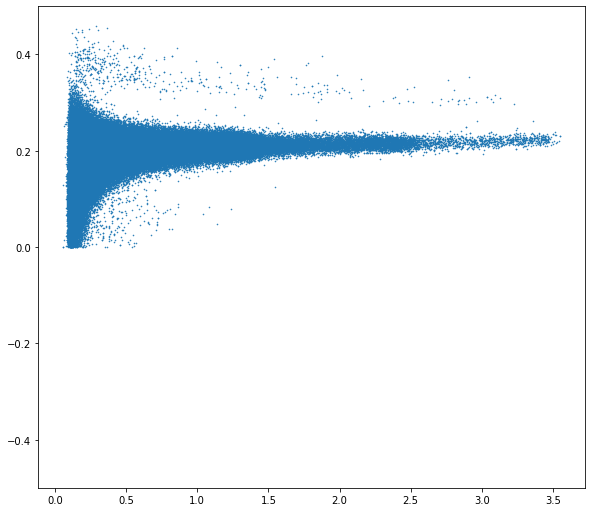

In [3]:
# Plot PSD
fig, ax = plot_scatter(psd_report["amplitude"], psd_report["tail / total"])
ax.set_ylim(-0.5,0.5)
fig.set_figheight(7)
fig.set_figwidth(8)

# Converting Voltage to Light Output

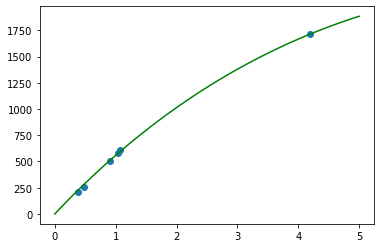

In [4]:
# plt.plot(np.linspace(0,5,50), exponential(np.linspace(0,5,50), *cali_params))

cal_x = np.array([0.4758, 1.0406, 0.9033, 0.3755, 1.0670, 4.1984])
cal_y = np.array([256.5, 581.87, 509.15, 206.8, 608.77, 1714.9])

def exponential(x, a, b, c, d):
    return a*np.exp(b*x) + c*np.exp(d*x)

def logarithmic(x, a, b, c):
    return a*np.log(b*x+1)+c*x


l_params, cov = curve_fit(
    logarithmic,
    cal_x,
    cal_y,
    bounds=((0, -20, -3e4),(20e3, 20, 3e3))
)

f_cal = np.poly1d(np.polyfit(cal_x, cal_y, 2))




xspace = np.linspace(0,5,50)
# plt.plot(xspace, f_cal(xspace) ,'r')
plt.plot(xspace, logarithmic(xspace,*l_params) ,'g')
plt.scatter(cal_x, cal_y)
# plt.ylim(0, 2000)
# plt.xlim(0.75,1.25)

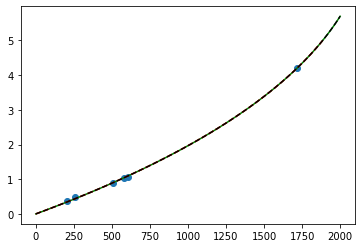

In [5]:
from pynverse import inversefunc

plt.scatter(cal_y, cal_x)
yspace = np.linspace(0,2000,100)
inv_vals = inversefunc(lambda x: logarithmic(x, *l_params), y_values=yspace)
f_l = np.poly1d(np.polyfit(yspace, inv_vals, 9))

plt.plot(yspace, inv_vals ,'g')
plt.plot(logarithmic(xspace,*l_params), xspace ,'r--')
plt.plot(yspace, f_l(yspace) ,'k--')

In [6]:
def v_to_l_0(voltage):
    V1 = 205 * 1e-3
    L1 = 900 * 1e-3
    V2 = 290 * 1e-3
    L2 = 1200 * 1e-3

    m = (L2-L1) / (V2-V1)
    b =  L1 - m * V1
    return m * voltage + b

def v_to_l(voltage):
    return f_l(voltage) * 1e3

psd_report["energy"] = psd_report["amplitude"].apply(v_to_l)

(0.0, 0.5)

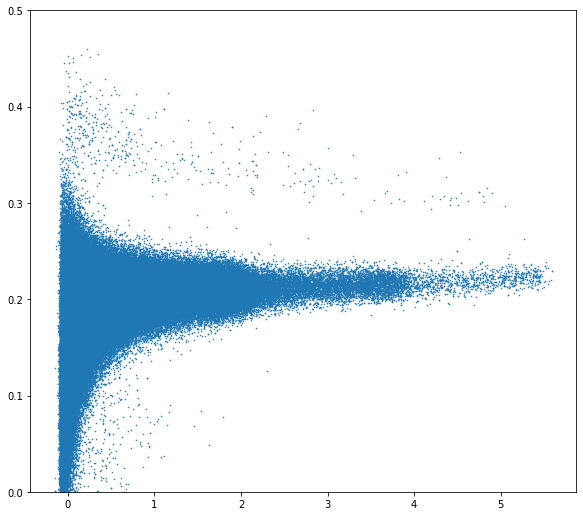

In [7]:
fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_ylim(0,0.5)

(0.0, 0.45)

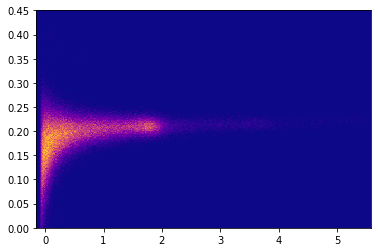

In [8]:
x, y = psd_report["energy"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, 300)
L4_e = xe[-2]
cmap = plt.colormaps["plasma"]
plt.pcolormesh(xe, ye, Z.T, cmap=cmap)
plt.ylim(0,0.45)

In [9]:
def sigma_slice(ye, counts, idx, lb, ub):
    return curve_fit(
        gaussian,
        ye[:-1], 
        counts[:,idx],
        bounds=(lb,ub)
    )


def get_gamma_bound_point(xe, ye, counts, idx, lb=(0.2,0.001,1), ub=(0.3,0.04,10_000)):
    energy = (xe[idx] + xe[idx + 1]) / 2
    (mu, sigma, A), cov = sigma_slice(ye, counts, idx, lb, ub)
    
    return energy, mu, sigma
    

counts = Z.T

energy = []
sigma = []
mu = []

min_i = 3
for idx in range(min_i, len(xe) - 1):
    e, m, s = get_gamma_bound_point(xe, ye, counts, idx)
    energy.append(e)
    sigma.append(s)
    mu.append(m)

In [10]:
from scipy.signal import savgol_filter

f_sigma = savgol_filter(sigma, 21, 3)
f_mu = savgol_filter(mu, 21, 3)

lower_bound = []
upper_bound = []
for s, m in zip(sigma,mu):
    lower_bound.append(m + 4*s)

offset = 0.2
f_lb = np.poly1d(np.polyfit(xe[min_i:-1], lower_bound, 9))

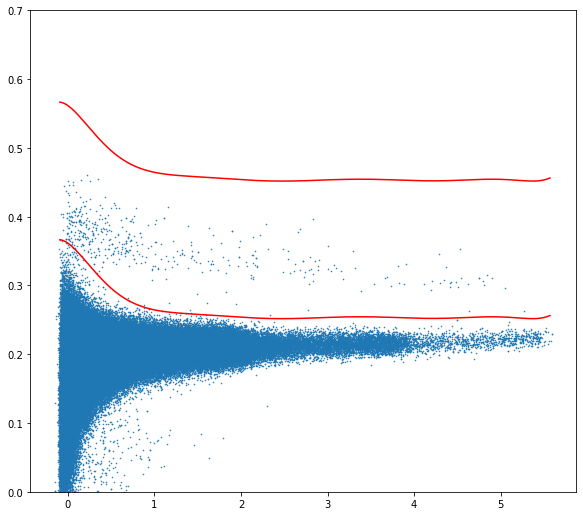

In [11]:
fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_ylim(0,0.7)

ax.plot(xe[min_i:-1], f_lb(xe[min_i:-1]), 'r-')
ax.plot(xe[min_i:-1], f_lb(xe[min_i:-1]) + offset, 'r-')

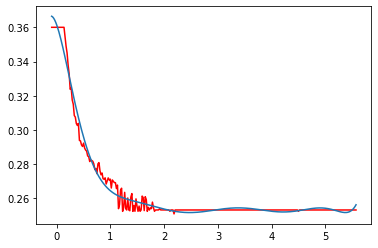

In [12]:
xe_r = np.linspace(0, xe[-1], 200)
plt.plot(xe[3:-1], lower_bound, 'r-')
plt.plot(xe[min_i:-1], f_lb(xe[min_i:-1]))

# Bounding Box

Find the bounding box with `n` sigma tolerance. Change `n` if necessary.



In [13]:
def lo_output(Ep):
    return 0.748*Ep-2.41*(1-np.exp(-0.298*Ep))

L1, L2, L3 = lo_output(np.array([2.5, 4.0, 6.0]))
L0 = 0.3323 # from AmBe Verf notebook
L1, L2, L3

(0.604109662855189, 1.3137083652773722, 2.481179562200148)

In [14]:
def classify_plot(psd_report, xe, f_lb, cutoffs=[L0, L1, L2, L3]):
    neutrons = psd_report[psd_report["tail / total"].between(f_lb(psd_report["energy"]), f_lb(psd_report["energy"]) + offset)]
    
    # plot distribution
    fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
    fig.set_figheight(7)
    fig.set_figwidth(8)
    ax.set_ylim(0,0.6)

    xe_r = np.linspace(xe[min_i], xe[-1], 200)

    # plot bounds
    ax.plot(xe_r, f_lb(xe_r), 'r-')
    ax.plot(xe_r, f_lb(xe_r) + offset, 'r-')

    # plot vlines
    ax.vlines(xe_r[0], f_lb(xe_r[0]), f_lb(xe_r[0]) + offset ,'r')
    ax.vlines(xe_r[0], f_lb(xe_r[0]), f_lb(xe_r[0]) + offset ,'r')
    ax.vlines(xe_r[-1], f_lb(xe_r[-1]), f_lb(xe_r[-1]) + offset, 'r')

    # plot neutrons
    ax.scatter(neutrons["energy"], neutrons["tail / total"], marker="o", s=3, c="orange")

    ax.set_title(f"$N={neutrons.shape[0]}$", fontsize=18)
    ax.set_ylabel("PSD")
    ax.set_xlabel("Energy (MeVee)")

    for lo in cutoffs:
        ax.vlines(lo, f_lb(lo), f_lb(lo) + offset, 'k')
    
    return fig, ax, neutrons

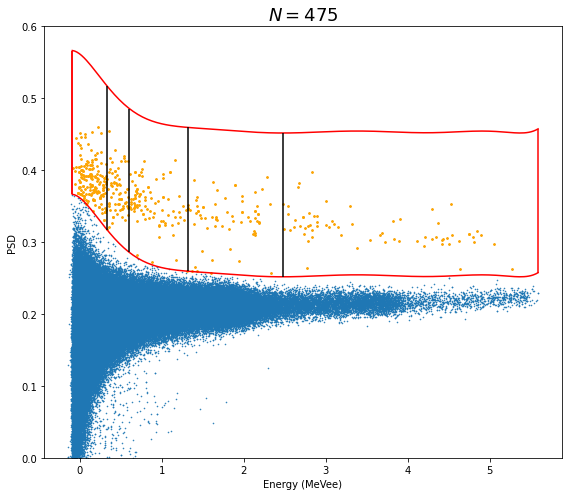

In [15]:
fig, ax, neutrons = classify_plot(psd_report, xe, f_lb)
fig.tight_layout()

# Altogether

In [16]:
EXP_NAME = "echem_exp"
ROOT = Path("../sample_datasets/20220801_experiments/")

ECHEM_ROOT = ROOT / "echem"
EPLAS_ROOT = ROOT / "echem_plasma"
PLAS_ROOT = ROOT / "plasma"
BG_ROOT = ROOT / "bg"

psd = pd.read_csv(EPLAS_ROOT / "total-tail.csv", header=None)
psd = pd.DataFrame([psd[1] / psd[0]]).T
amplitudes = pd.read_csv(EPLAS_ROOT / "amplitudes.csv", header=None)
eplas_df = pd.concat([psd, amplitudes], axis=1)
eplas_df.columns = ["tail / total", "amplitude"]
eplas_df = eplas_df.dropna(axis=0)
eplas_df["energy"] = (eplas_df["amplitude"]).apply(v_to_l)

psd = pd.read_csv(PLAS_ROOT / "total-tail.csv", header=None)
psd = pd.DataFrame([psd[1] / psd[0]]).T
amplitudes = pd.read_csv(PLAS_ROOT / "amplitudes.csv", header=None)
plas_df = pd.concat([psd, amplitudes], axis=1)
plas_df.columns = ["tail / total", "amplitude"]
plas_df = plas_df.dropna(axis=0)
plas_df["energy"] = (plas_df["amplitude"]).apply(v_to_l)


psd = pd.read_csv(BG_ROOT / "total-tail.csv", header=None)
psd = pd.DataFrame([psd[1] / psd[0]]).T
amplitudes = pd.read_csv(BG_ROOT / "amplitudes.csv", header=None)
bg_df = pd.concat([psd, amplitudes], axis=1)
bg_df.columns = ["tail / total", "amplitude"]
bg_df = bg_df.dropna(axis=0)
bg_df["energy"] = (bg_df["amplitude"]).apply(v_to_l)

(0.0, 0.5)

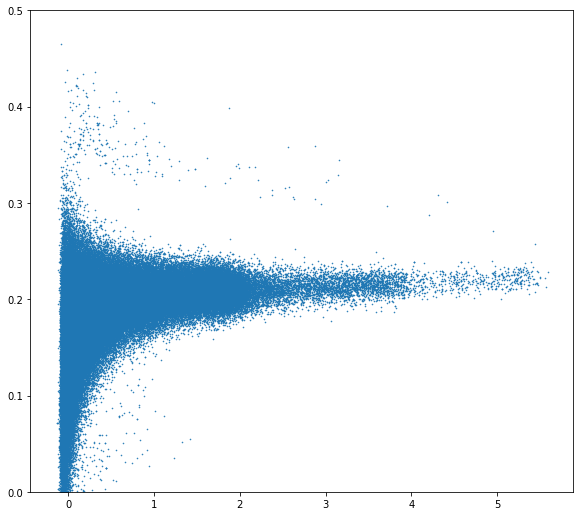

In [17]:
fig, ax = plot_scatter(bg_df["energy"], bg_df["tail / total"])
# ax.scatter(plas_df["energy"], plas_df["tail / total"], s=0.5)
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_ylim(0,0.5)

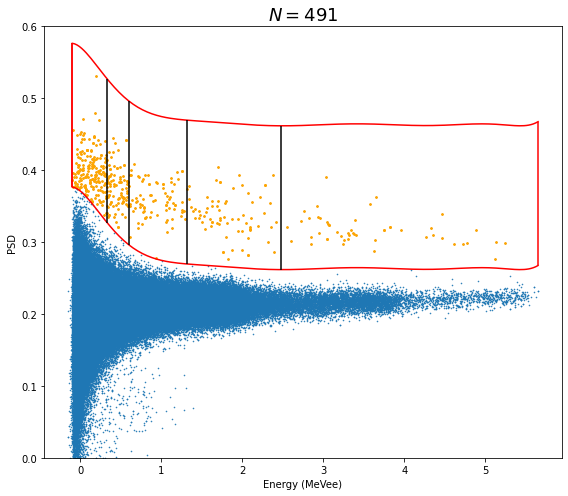

In [18]:
x, y = eplas_df["energy"], eplas_df["tail / total"]
Z, xe, ye = np.histogram2d(x, y, 300)
L4_ep = xe[-2]
counts = Z.T

energy = []
sigma = []
mu = []

min_i = 3
offset = 0.2
for idx in range(min_i, len(xe) - 1):
    e, m, s = get_gamma_bound_point(xe, ye, counts, idx, lb=(0.2,0.001,1),ub=(0.25,0.02,10_000))
    energy.append(e)
    sigma.append(s)
    mu.append(m)
    
f_lb_ep = np.poly1d(np.polyfit(xe[min_i:-1], lower_bound, 9)) + 0.01

fig, ax, neutrons_ep = classify_plot(eplas_df, xe, f_lb_ep)
# ax.set_xlim(0.1,1)
# ax.set_ylim(0,0.8)

fig.tight_layout()

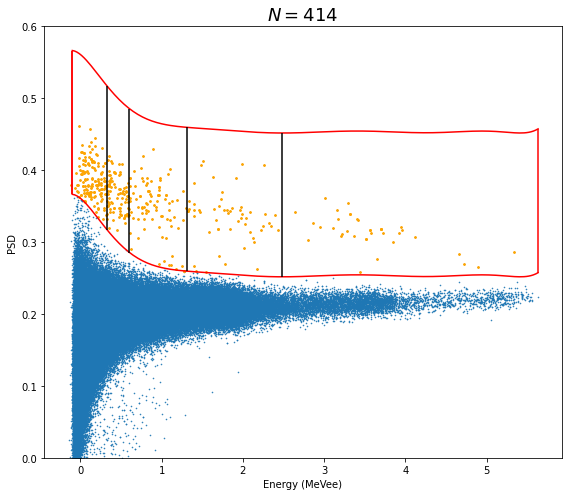

In [19]:
x, y = plas_df["energy"], plas_df["tail / total"]
Z, xe, ye = np.histogram2d(x, y, 300)
L4_p = xe[-2]
counts = Z.T

energy = []
sigma = []
mu = []

min_i = 3
offset = 0.2
for idx in range(min_i, len(xe) - 1):
    # print(idx)
    e, m, s = get_gamma_bound_point(xe, ye, counts, idx, lb=(0.20,0.001,1),ub=(0.24,0.05,10_000))
    energy.append(e)
    sigma.append(s)
    mu.append(m)
    
f_lb_p = np.poly1d(np.polyfit(xe[min_i:-1], lower_bound, 9))

fig, ax, neutrons_p = classify_plot(plas_df, xe, f_lb_p)
# ax.set_xlim(0.1, 0.8)
# ax.set_ylim(0,0.8)

fig.tight_layout()

C:\Users\Alvin\Desktop\Thunderbird\thunderbird_psd\.venv\lib\site-packages\scipy\optimize\_minpack_py.py:815: RuntimeWarning: divide by zero encountered in true_divide
  pcov = np.dot(VT.T / s**2, VT)


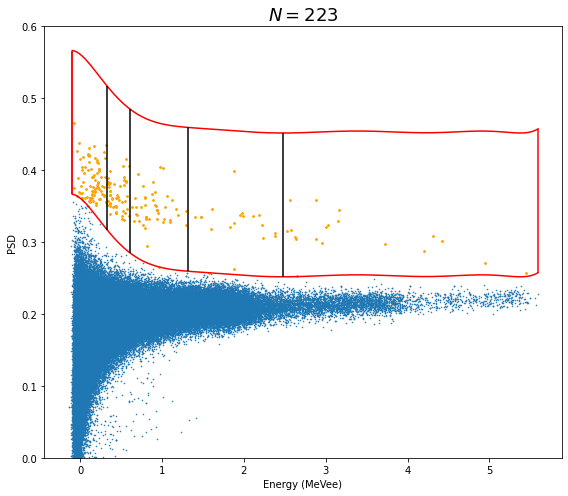

In [20]:
x, y = bg_df["energy"], bg_df["tail / total"]
Z, xe, ye = np.histogram2d(x, y, 300)
L4_bg = xe[-2]
counts = Z.T

energy = []
sigma = []
mu = []

min_i = 3
offset = 0.2
for idx in range(min_i, len(xe) - 1):
    # print(idx)
    e, m, s = get_gamma_bound_point(xe, ye, counts, idx, lb=(0.20,0.001,1),ub=(0.24,0.02,10_000))
    energy.append(e)
    sigma.append(s)
    mu.append(m)
    
f_lb_bg = np.poly1d(np.polyfit(xe[min_i:-1], lower_bound, 9))

fig, ax, neutrons_bg = classify_plot(bg_df, xe, f_lb_bg)
# ax.set_xlim(0.1, 0.8)
# ax.set_ylim(0,0.8)

fig.tight_layout()

In [21]:
t = 2371.31
t_ep = 2352.48
t_p = 2000.05
t_bg = 11200.69

def get_bounded_counts(psd, Ll, Lr):
    return psd[psd["energy"].between(Ll, Lr)].shape[0]

def get_rates_sigmas(neutrons, t, L1=L1, L2=L2, L3=L3, L4=10):
    r1 = get_bounded_counts(neutrons, L1, L2) / t
    r2 = get_bounded_counts(neutrons, L2, L3) / t
    r3 = get_bounded_counts(neutrons, L3, L4) / t
    
    return [r1,r2,r3], np.sqrt(np.array([r1, r2, r3]) * t) / t

rates_e, sigmas_e = get_rates_sigmas(neutrons, t, L4=L4_e)
rates_ep, sigmas_ep = get_rates_sigmas(neutrons_ep, t_ep, L4=L4_ep)
rates_p, sigmas_p = get_rates_sigmas(neutrons_p, t_p, L4=L4_p)
rates_bg, sigmas_bg = get_rates_sigmas(neutrons_bg, t_bg, L4=L4_bg)

# Here we go

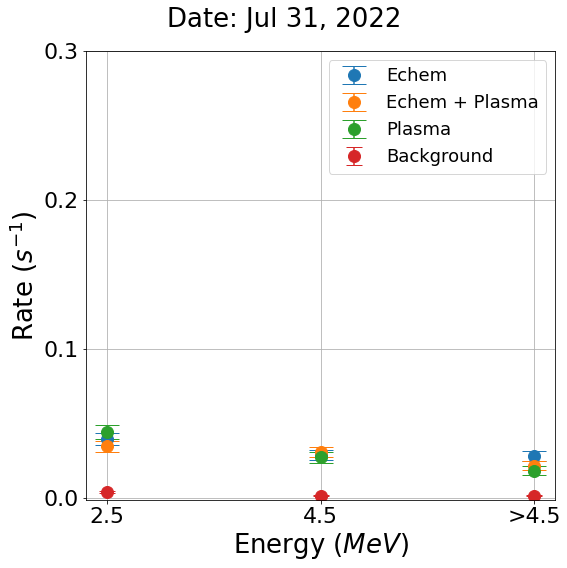

In [22]:
bins = ["2.5", "4.5", ">4.5"]

fig, ax = plt.subplots(figsize=(8,8))
ax.errorbar(bins, rates_e, yerr=sigmas_e, fmt = "o", markersize=12, linestyle="", label="Echem", capsize=12)
ax.errorbar(bins, rates_ep, yerr=sigmas_ep, fmt = "o", markersize=12, linestyle="", label="Echem + Plasma", capsize=12)
ax.errorbar(bins, rates_p, yerr=sigmas_p, fmt = "o", markersize=12, linestyle="", label="Plasma", capsize=12)
ax.errorbar(bins, rates_bg, yerr=sigmas_bg, fmt = "o", markersize=12, linestyle="", label="Background", capsize=8)

ax.set_ylabel("Rate $(s^{{-1}})$", fontsize=26)
ax.set_xlabel("Energy $(MeV)$", fontsize=26)
# ax.set_ylim(0.0, 0.3)
ax.set_yticks(np.arange(0,0.4,0.1))
fig.suptitle("Date: Jul 31, 2022", fontsize=26)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
ax.grid()
ax.legend(fontsize=18)
fig.tight_layout()
plt.show()

# Appendix Exploration

In [23]:
i = 25
zeta = Z.T
xe[i], zeta[:,i]

(0.3248387904040751,
 array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,

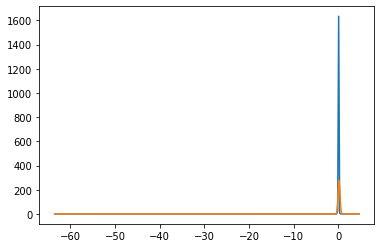

In [24]:
params, _ = curve_fit(
    gaussian,
    ye[:-1], 
    zeta[:,i],
    bounds=((0.2,0.001,1),(0.3,0.2,300))
)

plt.plot(ye[:-1], zeta[:,i])
plt.plot(ye[:-1], gaussian(ye[:-1], *params))
# plt.xlim(0.2,0.3)
# plt.yscale("log")